┌ Warning: type Lattices.Coordinate{2,Int64} does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/qcxKY/src/data/reconstructing_datatypes.jl:588
┌ Warning: type Main.CombinationIndexer{JLD2.ReconstructedStatic{Symbol("Coordinate{2,Int64}"), (:coordinates,), Tuple{Tuple{Int64, Int64}}}} does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/qcxKY/src/data/reconstructing_datatypes.jl:588
┌ Warning: some parameters could not be resolved for type Set{JLD2.ReconstructedStatic{Symbol("Coordinate{2,Int64}"), (:coordinates,), Tuple{Tuple{Int64, Int64}}}}; reading as Set{JLD2.ReconstructedStatic{Symbol("Coordinate{2,Int64}"), (:coordinates,), Tuple{Tuple{Int64, Int64}}}}
└ @ JLD2 ~/.julia/packages/JLD2/qcxKY/src/data/reconstructing_datatypes.jl:580
┌ Warning: custom serialization of Dict{JLD2.ReconstructedStatic{Symbol("Coordinate{2,Int64}"), (:coordinates,), Tuple{Tuple{Int64, Int64}}},Nothing} encountered, but the type does not exist in the workspac

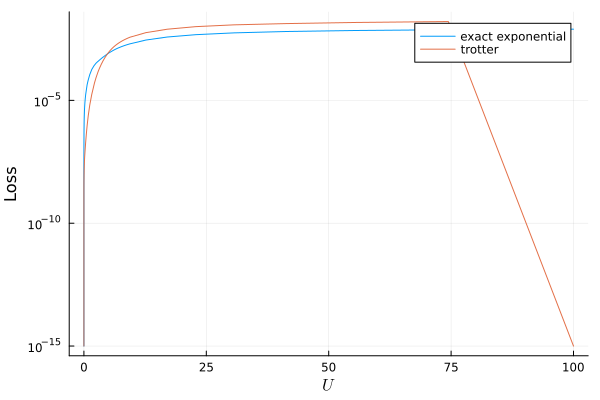

In [2]:
include("trotter.jl")
using .Trotter
using Plots
using JLD2
using LaTeXStrings

U_values = nothing
losses = zeros((2, 61))
folder = "data/N=(4, 4)_3x3_2"
for file in readdir(folder)
    m = match(r"(?<L>.+)_u_(?<u>\d+).jld2", file)
    if m !== nothing
        label = m[:L]
        u_i = parse(Int,m[:u])
        # println(label," ", u_i)
        if occursin("unitary_map_energy_symmetry=false", label)
            k = 1
            text_label = "exact exp"
        elseif occursin("trotter_", label) && !occursin("loss_energy", label)
            k = 2
            text_label = "trotter"
        else
            continue
        end
        data = load(joinpath(folder, file))
        # println(data["dict"]["metrics"])
        loss = data["dict"]["metrics"]["loss"][end]
        # display(data["dict"])
        # break
        # println("$text_label (u=$(u_i)): $loss")
        losses[k, u_i] = loss
    elseif occursin("meta_data", file)
        data = load(joinpath(folder, file))
        U_values = data["dict"]["meta_data"]["U_values"]

    end
end
p = plot(xlabel=L"U", ylabel="Loss", yscale=:log10)
plot!(p, U_values, max.(losses[1,:],1e-15), label="exact exponential")
plot!(p, U_values, max.(losses[2,:],1e-15), label="trotter")
display(p)

In [4]:
include("trotter.jl")
using .Trotter

using Lattices
using LinearAlgebra
using SparseArrays
using JLD2
using HDF5
using Plots
using LaTeXStrings

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Trotterization order comparison:
#   1. Exact exponential energy (exact-exp optimized coefficients applied as-is)
#   2. Trotterized energy for different orders P = 1, 2, 4, 8
#      (exact-exp coefficients repeated P times, each copy divided by P)
#   3. Trotter-optimized energy (from trotter_N=9_loss_energy files)
# Assumption: unitary_map_energy_symmetry=false coefficients optimized energy.
# Note: all_full_eig_vecs in meta_data is (9 sectors) × (61 U-vals, 1764 full-space dim);
#   we recompute sector-restricted ground states via eigen for correctness.
# ─────────────────────────────────────────────────────────────────────────────



# ── 1. Configuration ──────────────────────────────────────────────────────────
const FOLDER         = "data/N=(4, 4)_3x3_2"
const LVEC           = [3, 3]     # lattice dimensions W×H
const N_UP           = 4
const N_DN           = 4
# Trotter orders P to compare (P=1 = exact single application, P>1 = Trotterized)
const TROTTER_ORDERS = [1, 2, 4, 8]

# ── 2. Load U_values from meta_data ────────────────────────────────────────────
meta     = load(joinpath(FOLDER, "meta_data_and_E.jld2"))["dict"]
U_values = meta["meta_data"]["U_values"]
n_U      = length(U_values)
println("Loaded U_values: $n_U entries, range $(U_values[1]) to $(U_values[end])")

# ── 3. Build momentum-sector Hamiltonians, basis, gates ──────────────────────
N_sites = prod(LVEC)

# Derive q_target: first try the trotter shared file's instructions, then HDF5
shared_trotter = load(joinpath(FOLDER, "trotter_N=$(N_sites)_loss_energy_shared.jld2"))["dict"]
inst           = shared_trotter["instructions"]

local q_target = get(inst, "q_target", nothing)
if isnothing(q_target)
    h5_files = [f for f in readdir(FOLDER) if occursin("HubbardED", f)]
    if !isempty(h5_files)
        h5_file = joinpath(FOLDER, h5_files[1])
        q_target = h5open(h5_file, "r") do data
            key_labels = [parse(Int, k) for k in keys(data["data/energies"])]
            all_E = [real.(read(data, "data/energies/$(k)"))[:, 1] for k in key_labels]
            k_min = key_labels[argmin([minimum(e) for e in all_E])]
            kvecs = read(data, "metadata/kvecs")
            k_tuple = tuple((kvecs[:, k_min+1] .+ 1)...)
            Trotter.ravel_c(k_tuple .- 1, Tuple(LVEC))
        end
    else
        q_target = 0  # default: Gamma point
    end
end
println("q_target = $q_target")

println("Building sector Hamiltonians...")
@time H_hop_mom, basis_dict, _ = TamFermion.HubbardMomentumBasis(1.0, 0.0, LVEC, (N_UP, N_DN); q_target=q_target)
@time H_int_mom, _, _          = TamFermion.HubbardMomentumBasis(0.0, 1.0, LVEC, (N_UP, N_DN); q_target=q_target)
basis_ints = basis_dict["ints"]
dim        = length(basis_ints)
println("Hilbert space sector dim = $dim")

println("Enumerating Trotter gates...")
@time gates     = TamFermion.enumerate_ferm_excitations(2, LVEC; conserve_mom=true, conserve_sz=true, include_diagonal=true)
@time tau_terms = TamFermion.fgateToTauSector(gates, N_sites, basis_ints)
num_gates = length(gates)
println("num_gates = $num_gates")

# ── 4. Load exact-exp coefficients for each U ─────────────────────────────────
# Per-u files store 'coefficients' as Vector{Any}; we extract the first non-Nothing
# Float64 sub-array, which is the optimized coefficient vector for that U step.
unitary_prefix = "unitary_map_energy_symmetry=false_N=($(N_UP), $(N_DN))"

function load_exact_exp_coefficients(folder, prefix, u_i)
    fpath = joinpath(folder, "$(prefix)_u_$(u_i).jld2")
    isfile(fpath) || return nothing
    d = load(fpath)["dict"]
    raw = d["coefficients"]
    for elem in raw
        if elem isa AbstractArray{<:Number}
            return Float64.(elem)
        end
    end
    return nothing
end

exact_coeffs = [load_exact_exp_coefficients(FOLDER, unitary_prefix, u_i) for u_i in 1:n_U]
n_loaded = sum(!isnothing, exact_coeffs)
println("Loaded exact-exp coefficients for $n_loaded / $n_U U values")
if n_loaded > 0
    first_nz = findfirst(!isnothing, exact_coeffs)
    println("  First non-nothing: u_i=$first_nz, length=$(length(exact_coeffs[first_nz]))")
end

# ── 5. Compute sector-restricted ground states via eigen ──────────────────────
# We use the sector Hamiltonian H_hop_mom + U*H_int_mom to get exact ground states.
# These serve as both the reference (U_idx=1) and the comparison ground-state energy.
println("\nComputing sector ground states via eigen ($(n_U) U values)...")
gs_states  = Vector{Vector{ComplexF64}}(undef, n_U)
gs_energies = fill(NaN, n_U)

for u_i in 1:n_U
    H_u = H_hop_mom + U_values[u_i] * H_int_mom
    # Use real symmetric solver (H is real Hermitian for Hubbard)
    vals, vecs = eigen(Symmetric(Matrix(real(H_u))))
    gs_states[u_i]  = ComplexF64.(vecs[:, 1])
    gs_energies[u_i] = vals[1]
end
println("  Done")

# Reference state: ground state at U_idx=1 (same convention as scan script)
ref_state = gs_states[1]
compute_energy(psi, H) = real(dot(psi, H * psi))

# ── 6. Compute exact-exp energies (apply stored coeffs as single-layer unitary) ─
println("\nComputing exact-exp energies...")
exact_exp_energies = fill(NaN, n_U)
for u_i in 1:n_U
    A = exact_coeffs[u_i]
    isnothing(A) && continue
    if length(A) % num_gates != 0
        @warn "u_i=$u_i: coeff length $(length(A)) not divisible by num_gates=$num_gates"
        continue
    end
    stored_num_exp = length(A) ÷ num_gates
    psi = TrotterOptimization.apply_unitary(A, gates, ref_state, basis_ints, N_sites, stored_num_exp)
    H_u = H_hop_mom + U_values[u_i] * H_int_mom
    exact_exp_energies[u_i] = compute_energy(psi, H_u)
end
println("  Done ($(sum(!isnan, exact_exp_energies)) non-NaN values)")

# ── 7. Compute trotterized energies: coeffs repeated P times, scaled 1/P ────────
# Approximates exp(A·G) ≈ [exp((A/P)·G)]^P by repeating the gate sequence P times
# with coefficient A/P per step. At high P this converges to the exact exponential
# (in the limit that the gates commute, i.e., perfect Trotterization).
println("\nComputing trotterized energies for orders P = $TROTTER_ORDERS...")
trotter_energies = Dict{Int, Vector{Float64}}()

for P in TROTTER_ORDERS
    energies_P = fill(NaN, n_U)
    for u_i in 1:n_U
        A_base = exact_coeffs[u_i]
        isnothing(A_base) && continue
        length(A_base) % num_gates == 0 || continue
        stored_num_exp = length(A_base) ÷ num_gates
        # Scale each coefficient by 1/P, repeat P times to get P×stored layers
        A_trotter = repeat(A_base, P) ./ P
        total_exp = P * stored_num_exp
        psi = TrotterOptimization.apply_unitary(A_trotter, gates, ref_state, basis_ints, N_sites, total_exp)
        H_u = H_hop_mom + U_values[u_i] * H_int_mom
        energies_P[u_i] = compute_energy(psi, H_u)
    end
    trotter_energies[P] = energies_P
    println("  P=$P: $(sum(!isnan, energies_P)) non-NaN values")
end

# ── 8. Load trotter-optimized energies (energy-loss optimization) ─────────────
println("\nLoading trotter-optimized (energy-loss) results...")
trotter_prefix       = "trotter_N=$(N_sites)_loss_energy"
trotter_opt_energies = fill(NaN, n_U)

for u_i in 1:n_U
    fpath = joinpath(FOLDER, "$(trotter_prefix)_u_$(u_i).jld2")
    if isfile(fpath)
        d = load(fpath)["dict"]
        met = d["metrics"]
        if haskey(met, "loss") && !isempty(met["loss"])
            trotter_opt_energies[u_i] = met["loss"][end]
        end
    end
end
println("  Loaded $(sum(!isnan, trotter_opt_energies)) trotter-opt energy values")

# ── 9. Plot: energy vs U for all methods ──────────────────────────────────────
println("\nPlotting...")
p = plot(
    xlabel  = L"U",
    ylabel  = "Energy",
    title   = "Hamiltonian energy vs Trotterization order\n(3×3 lattice, N↑=$N_UP, N↓=$N_DN)",
    legend  = :outerright,
    size    = (1000, 550),
    margin  = 5Plots.mm,
)

# Ground-state reference (exact diagonalization)
valid = .!isnan.(gs_energies)
plot!(p, U_values[valid], gs_energies[valid];
    label = "Ground state (ED)",
    color = :black,
    lw    = 2,
    ls    = :dash,
)

# Exact exponential: stored coeffs applied as-is (single or multi-layer unitary)
valid = .!isnan.(exact_exp_energies)
plot!(p, U_values[valid], exact_exp_energies[valid];
    label      = "Exact exp (energy-opt coeffs, applied as-is)",
    color      = :blue,
    lw         = 2,
    marker     = :circle,
    markersize = 4,
)

# Trotterized energies for each P
trotter_palette = [:red, :orange, :purple, :darkgreen]
for (idx, P) in enumerate(TROTTER_ORDERS)
    energies_P = trotter_energies[P]
    valid = .!isnan.(energies_P)
    plot!(p, U_values[valid], energies_P[valid];
        label      = "Trotterized P=$P (coeffs/P, repeated P×)",
        color      = trotter_palette[idx],
        lw         = 1.5,
        marker     = :square,
        markersize = 3,
    )
end

# Trotter-optimized energy (energy-loss optimization)
valid = .!isnan.(trotter_opt_energies)
plot!(p, U_values[valid], trotter_opt_energies[valid];
    label      = "Trotter opt (energy-loss optimized)",
    color      = :cyan,
    lw         = 2,
    marker     = :diamond,
    markersize = 4,
)

display(p)